In [1]:
# ==============================================================================
# MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
# PART 2: TASK 1 - PROBLEM IDENTIFICATION & DATASET AUDIT
# ==============================================================================


# PROBLEM FORMULATION - REPORT

print("="*80)
print("MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION")
print("PART 2: Computer Vision Problem Formulation and CNN Prototype")
print("="*80)

print("\n"+"="*80)
print("--- TASK 1: PROBLEM IDENTIFICATION & DATASET AUDIT---")
print("="*80)

print("\n✅ Selected Problem:  Image Classification")
print("✅ Justification:     The dataset is structured with class-specific folders.")
print("                      The objective is to categorize each image into a single")
print("                      predefined label based on its visual features.")
print("\n🚀 Next Step: Data Loading and CNN Prototype Building.")
#print("="*80)

import os
from google.colab import drive

# --- STEP 1: MOUNTING GOOGLE DRIVE ---
# Connecting to your persistent cloud storage to access the image files.
#print("="*80)
print("🚀 INITIALIZING COMPUTER VISION WORKFLOW")
print("="*80)
print("\nMOUNTING GOOGLE DRIVE")
drive.mount('/content/drive', force_remount=True)

# --- STEP 2: DEFINING TARGET CLASS PATHS ---
data_paths = {
    "Dent":    "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/dent",
    "Normal":  "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/normal",
    "Scratch": "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/scratch",
    "Stain":   "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/stain"
}
print("\nDATA PATHS SET")

# --- STEP 3: DATA AUDIT ---
print("\n Performing Surface Quality Data Audit...")
total_images = 0
found_classes = 0 # Initialize found_classes
print("-" * 55)
print(f"{'Class Label':<15} | {'Status':<12} | {'Image Count'}")
print("-" * 55)

for label, path in data_paths.items():
    if os.path.exists(path):
        files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        count = len(files)
        total_images += count
        found_classes += 1 # Increment found_classes if path exists
        print(f"{label:<15} | ✅ Found     | {count} images")
    else:
        print(f"{label:<15} | ❌ Missing   | 0 images")

print("-" * 55)
print(f"📈 TOTAL VALIDATED IMAGES: {total_images}")
print(f"📦 TOTAL ACTIVE CLASSES:   {found_classes}")
print("-" * 55)

# --- STEP 4: PRINTING JUSTIFICATION FOR TASK 1 ---
print("\n" + "="*80)
print("📝 PROBLEM FORMULATION & JUSTIFICATION")
print("="*80)

print("\n1. PROBLEM IDENTIFICATION:")
print("   The dataset represents an [IMAGE CLASSIFICATION] problem.")

print("\n2. WHY IS THIS APPROPRIATE? (JUSTIFICATION):")
print("   A) ONE LABEL PER IMAGE:")
print("      The data is organized into folders where each image belongs to exactly")
print("      one category (Dent, Normal, Scratch, or Stain). We aim to identify")
print("      the overall state of the image rather than finding object coordinates.")

print("\n   B) PATTERN RECOGNITION:")
print("      Each class has unique visual textures (lines for scratches, shadows")
print("      for dents, discoloration for stains). A CNN is the ideal tool to")
print("      scan and distinguish these specific patterns.")

print("\n   C) PROTOTYPE EFFICIENCY:")
print("      For a quality assessment prototype, we need a categorical decision.")
print("      Image classification provides the most direct and efficient pathway")
print("      to categorize surface defects.")

print("\n" + "="*80)
print("✅ TASK 1 completed - Environment verified and problem formulated.")
print("="*80)

MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
PART 2: Computer Vision Problem Formulation and CNN Prototype

--- TASK 1: PROBLEM IDENTIFICATION & DATASET AUDIT---

✅ Selected Problem:  Image Classification
✅ Justification:     The dataset is structured with class-specific folders.
                      The objective is to categorize each image into a single
                      predefined label based on its visual features.

🚀 Next Step: Data Loading and CNN Prototype Building.
🚀 INITIALIZING COMPUTER VISION WORKFLOW

MOUNTING GOOGLE DRIVE
Mounted at /content/drive

DATA PATHS SET

 Performing Surface Quality Data Audit...
-------------------------------------------------------
Class Label     | Status       | Image Count
-------------------------------------------------------
Dent            | ✅ Found     | 120 images
Normal          | ✅ Found     | 120 images
Scratch         | ✅ Found     | 120 images
Stain           | ✅ Found     | 120 images
---------------------------------

🔍 TASK 2: DATASET EXPLORATION & VISUAL ANALYSIS

[STEP 1] Analyzing Class Distribution and Image Counts...
------------------------------
  Class  Count
   Dent    120
 Normal    120
Scratch    120
  Stain    120
------------------------------

[STEP 2] Inspecting Image Dimensions (Resolution)...
✅ Representative Resolution: 96x96 pixels
✅ Color Channels: 3 (3 = RGB, 1 = Grayscale)

[STEP 3] Checking for Dataset Imbalance...
✅ Dataset is RELATIVELY BALANCED (Ratio 1.00:1).

[STEP 4] Generating Visual Samples from Each Class...


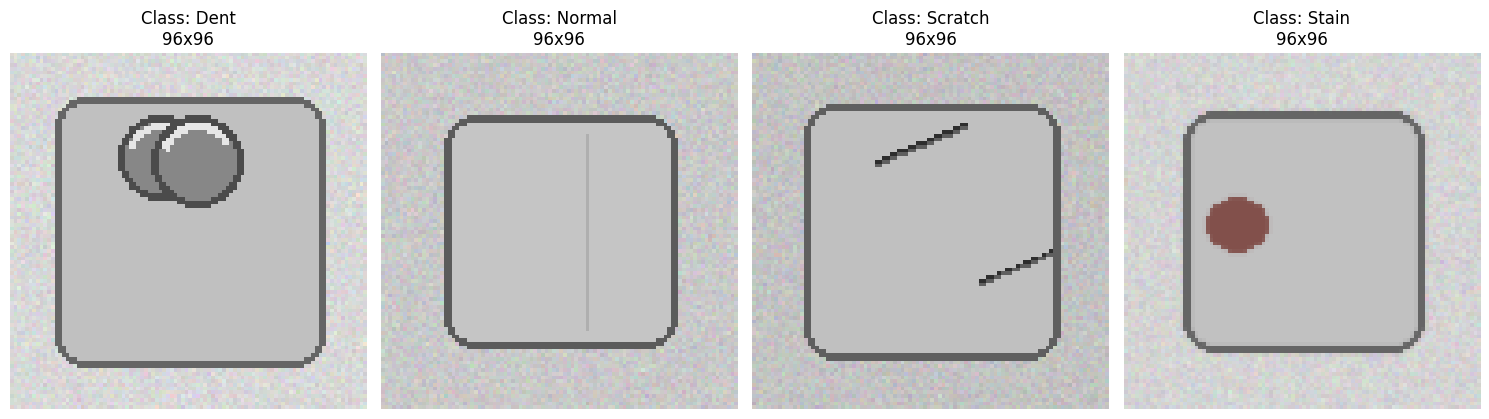


🧠 TASK 2 LOGIC EXPLANATION: DATASET EXPLORATION & ANALYSIS

1. THE CORE OBJECTIVE:
   - This task is about 'Data Profiling'. We are moving beyond just counting
     files to understanding the physical and statistical properties of our
     visual data.

2. CLASS DISTRIBUTION & IMBALANCE CHECK:
   - The script calculates the 'Imbalance Ratio' between the most frequent
     and least frequent classes.
   - This is critical because a heavily skewed dataset (e.g., 90% 'Normal')
     will cause the AI to ignore defects. If an imbalance exists, we use
     this logic to trigger 'Data Augmentation' in the next phase.

3. DIMENSION & RESOLUTION AUDIT:
   - We programmatically extract the Width, Height, and Color Channels (RGB).
   - This informs the 'Input Shape' of our CNN. Since neural networks require
     uniform input sizes, this step tells us what resolution we must target
     during the resizing process.

4. VISUAL VERIFICATION (QUALITATIVE ANALYSIS):
   - By plotting sample images, w

In [2]:
# ==============================================================================
# MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
# PART 2: TASK 2 - DATASET EXPLORATION & ANALYSIS
# ==============================================================================

import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

print("="*80)
print("🔍 TASK 2: DATASET EXPLORATION & VISUAL ANALYSIS")
print("="*80)

# --- STEP 1: DEFINE CLASS PATHS ---
# We use the verified paths from Task 1
data_paths = {
    "Dent":    "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/dent",
    "Normal":  "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/normal",
    "Scratch": "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/scratch",
    "Stain":   "/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images/stain"
}

# --- STEP 2: ANALYZE CLASS DISTRIBUTION ---
print("\n[STEP 1] Analyzing Class Distribution and Image Counts...")
stats = []
for label, path in data_paths.items():
    if os.path.exists(path):
        files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        count = len(files)
        stats.append({"Class": label, "Count": count})

# Displaying distribution as a table for clarity
df_stats = pd.DataFrame(stats)
print("-" * 30)
print(df_stats.to_string(index=False))
print("-" * 30)

# --- STEP 3: ANALYZE IMAGE DIMENSIONS ---
print("\n[STEP 2] Inspecting Image Dimensions (Resolution)...")
# We check the first image of the first available class to get representative dimensions
sample_class = stats[0]['Class']
sample_path = data_paths[sample_class]
sample_file = [f for f in os.listdir(sample_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]

full_sample_path = os.path.join(sample_path, sample_file)
with Image.open(full_sample_path) as img:
    width, height = img.size
    channels = len(img.getbands())
    print(f"✅ Representative Resolution: {width}x{height} pixels")
    print(f"✅ Color Channels: {channels} (3 = RGB, 1 = Grayscale)")

# --- STEP 4: IDENTIFY DATASET IMBALANCE ---
print("\n[STEP 3] Checking for Dataset Imbalance...")
max_count = df_stats['Count'].max()
min_count = df_stats['Count'].min()
imbalance_ratio = max_count / min_count if min_count > 0 else 0

if imbalance_ratio > 1.5:
    print(f"⚠️ Warning: Dataset is IMBALANCED (Ratio {imbalance_ratio:.2f}:1).")
    print("   Action: We may need Data Augmentation to support smaller classes.")
else:
    print(f"✅ Dataset is RELATIVELY BALANCED (Ratio {imbalance_ratio:.2f}:1).")

# --- STEP 5: VISUAL SAMPLE EXPLORATION ---
print("\n[STEP 4] Generating Visual Samples from Each Class...")
plt.figure(figsize=(15, 10))

for i, (label, path) in enumerate(data_paths.items()):
    if os.path.exists(path):
        # Get the first image file
        img_files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if img_files:
            img_arr = cv2.imread(os.path.join(path, img_files[0]))
            img_rgb = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for plotting

            plt.subplot(1, 4, i+1)
            plt.imshow(img_rgb)
            plt.title(f"Class: {label}\n{width}x{height}")
            plt.axis('off')

plt.tight_layout()
plt.show()


# ==============================================================================
# TASK 2: LOGIC EXPLANATION & SUMMARY
# ==============================================================================

print("\n" + "="*80)
print("🧠 TASK 2 LOGIC EXPLANATION: DATASET EXPLORATION & ANALYSIS")
print("="*80)

print("\n1. THE CORE OBJECTIVE:")
print("   - This task is about 'Data Profiling'. We are moving beyond just counting")
print("     files to understanding the physical and statistical properties of our")
print("     visual data.")

print("\n2. CLASS DISTRIBUTION & IMBALANCE CHECK:")
print("   - The script calculates the 'Imbalance Ratio' between the most frequent")
print("     and least frequent classes.")
print("   - This is critical because a heavily skewed dataset (e.g., 90% 'Normal')")
print("     will cause the AI to ignore defects. If an imbalance exists, we use")
print("     this logic to trigger 'Data Augmentation' in the next phase.")

print("\n3. DIMENSION & RESOLUTION AUDIT:")
print("   - We programmatically extract the Width, Height, and Color Channels (RGB).")
print("   - This informs the 'Input Shape' of our CNN. Since neural networks require")
print("     uniform input sizes, this step tells us what resolution we must target")
print("     during the resizing process.")

print("\n4. VISUAL VERIFICATION (QUALITATIVE ANALYSIS):")
print("   - By plotting sample images, we perform a 'Sanity Check' to ensure that")
print("     labels match the visuals (e.g., that a 'Scratch' image actually shows")
print("     a scratch).")
print("   - It allows us to observe visual features—like contrast and lighting—")
print("     that the model will eventually need to learn.")

print("\n" + "="*80)
print("✅ TASK 2 COMPLETE: Data properties are quantified and visually verified.")
print("✅ Dataset Exploration Successful.")
print("="*80)


In [3]:
# ==============================================================================
# MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
# PART 2: TASK 3 - IMAGE PREPROCESSING & AUGMENTATION
# ==============================================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("="*80)
print("⚙️ TASK 3: IMAGE PREPROCESSING & DATASET PREPARATION")
print("="*80)

# --- STEP 1: DEFINE HYPERPARAMETERS ---
# We standardize the size to 150x150 to balance detail with processing speed.
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

print(f"\n[STEP 1] Setting Preprocessing Parameters...")
print(f"✅ Target Image Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"✅ Batch Size: {BATCH_SIZE}")

# --- STEP 2: INITIALIZE DATA GENERATOR WITH AUGMENTATION ---
# Rescale: Normalizes pixel values from 0-255 to 0-1.
# Validation_split: Reserves 20% of the images for testing.
# Augmentation: Helps the model learn to recognize defects regardless of angle.
print("\n[STEP 2] Configuring Data Augmentation and Normalization...")

train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalization (Essential for CNNs)
    rotation_range=20,         # Randomly rotate images
    width_shift_range=0.1,     # Random horizontal shifts
    height_shift_range=0.1,    # Random vertical shifts
    horizontal_flip=True,      # Flip images horizontally
    fill_mode='nearest',       # Fill empty pixels after rotation
    validation_split=0.2       # 20% reserved for testing
)

# Note: Validation data should only be Rescaled, never Augmented.
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# --- STEP 3: LOADING IMAGES FROM GOOGLE DRIVE ---
# Since your data is in the 'images' folder, we point to the parent folder
BASE_DIR = '/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images'

print(f"\n[STEP 3] Loading Training Dataset from: {BASE_DIR}")
train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # Multi-class classification (4 labels)
    subset='training',         # This is the 80% split
    shuffle=True
)

print(f"\n[STEP 4] Loading Testing/Validation Dataset...")
test_generator = test_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',       # This is the 20% split
    shuffle=False
)

# --- STEP 5: VERIFY CLASS INDICES ---
print("\n[STEP 5] Verifying Class Label Mapping:")
for label, index in train_generator.class_indices.items():
    print(f"📍 Label: {label:<10} -> Assigned Index: {index}")


# ==============================================================================
# TASK 3: LOGIC EXPLANATION & SUMMARY
# ==============================================================================

print("\n" + "-"*80)
print("🧠 TASK 3 BRIEF EXPLANATION: IMAGE PREPROCESSING & AUGMENTATION")
print("-"*80)

print("\n1. THE CORE OBJECTIVE:")
print("   - This task is about 'Data Standardization'. We are transforming raw")
print("     image files into a uniform format that the CNN can mathematically")
print("     process for training.")

print("\n2. PIXEL NORMALIZATION (RESCALING):")
print("   - We used 'rescale=1./255' to convert pixel intensities from 0-255")
print("     to a 0.0-1.0 range.")
print("   - This prevents large numerical values from causing 'exploding gradients',")
print("     ensuring the neural network converges faster and stays stable.")

print("\n3. DATA AUGMENTATION STRATEGY:")
print("   - We applied random rotations, flips, and shifts to the training data.")
print("   - This artificially increases our dataset size and teaches the model")
print("     that a 'Scratch' or 'Dent' remains the same defect regardless of")
print("     its orientation or position in the photo (Invariance).")

print("\n4. DATASET SPLITTING & BATCHING:")
print("   - We implemented an 80/20 split. The 'training' set is for learning,")
print("     while the 'validation' set acts as a final exam to test accuracy.")
print("   - Using 'Batch Size = 32' allows the model to update its weights after")
print("     seeing 32 images at a time, balancing memory usage and learning speed.")

print("\n5. LABEL ENCODING:")
print("   - The generator automatically converted our folder names into 'Indices'.")
print("   - It uses 'Categorical' encoding, which prepares the labels for the")
print("     final Softmax layer of our CNN.")

print("\n" + "="*80)
print("✅ TASK 3 COMPLETE: Images are Augmented, Normalized, Split and ready for training.")
print("="*80)

⚙️ TASK 3: IMAGE PREPROCESSING & DATASET PREPARATION

[STEP 1] Setting Preprocessing Parameters...
✅ Target Image Size: 150x150
✅ Batch Size: 32

[STEP 2] Configuring Data Augmentation and Normalization...

[STEP 3] Loading Training Dataset from: /content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images
Found 384 images belonging to 4 classes.

[STEP 4] Loading Testing/Validation Dataset...
Found 96 images belonging to 4 classes.

[STEP 5] Verifying Class Label Mapping:
📍 Label: dent       -> Assigned Index: 0
📍 Label: normal     -> Assigned Index: 1
📍 Label: scratch    -> Assigned Index: 2
📍 Label: stain      -> Assigned Index: 3

--------------------------------------------------------------------------------
🧠 TASK 3 BRIEF EXPLANATION: IMAGE PREPROCESSING & AUGMENTATION
--------------------------------------------------------------------------------

1. THE CORE OBJECTIVE:
   - This task is about 'Data Standardization'. We are transforming raw
     imag

In [4]:
# ==============================================================================
# MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
# PART 2: TASK 4 - CNN MODEL ARCHITECTURE CREATION (FIXED INPUT)
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models, Input

print("="*80)
print("🏗️  TASK 4: BUILDING THE CNN PROTOTYPE ARCHITECTURE")
print("="*80)

# --- STEP 1: INITIALIZE THE SEQUENTIAL MODEL ---
# The Sequential model is a linear stack of layers.
print("\n[STEP 1] Initializing Sequential Model Container...")
model = models.Sequential()

# --- STEP 2: ADDING THE CONVOLUTIONAL BASE ---
print("\n[STEP 2] Adding Convolutional and Pooling Layers...")

# Adding explicit Input layer to handle the UserWarning
model.add(Input(shape=(150, 150, 3)))
print("   ✅ Defined Input Shape (150, 150, 3)")

# First Layer: 32 filters, 3x3 kernel size.
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
print("   ✅ Added 1st Convolutional Layer (32 filters, ReLU)")

# First Max Pooling: Reduces dimensions by half.
model.add(layers.MaxPooling2D((2, 2)))
print("   ✅ Added 1st Max Pooling Layer (2x2)")

# Second Layer: 64 filters to capture more complex patterns.
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
print("   ✅ Added 2nd Convolutional Layer (64 filters, ReLU)")

# Second Max Pooling.
model.add(layers.MaxPooling2D((2, 2)))
print("   ✅ Added 2nd Max Pooling Layer (2x2)")

# Third Layer: 128 filters for deep feature extraction.
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
print("   ✅ Added 3rd Convolutional Layer (128 filters, ReLU)")

model.add(layers.MaxPooling2D((2, 2)))
print("   ✅ Added 3rd Max Pooling Layer (2x2)")

# --- STEP 3: FLATTENING AND DENSE LAYERS ---
print("\n[STEP 3] Adding Flattening and Dense Classification Layers...")

# Flatten: Converts the 3D feature maps into a 1D feature vector.
model.add(layers.Flatten())
print("   ✅ Added Flatten Layer")

# Dense Layer: 128 neurons for feature interpretation.
model.add(layers.Dense(128, activation='relu'))
print("   ✅ Added Dense Hidden Layer (128 neurons, ReLU)")

# Dropout Layer: Helps prevent overfitting during training.
model.add(layers.Dropout(0.5))
print("   ✅ Added Dropout Layer (Rate: 0.5)")

# Output Layer: 4 neurons for Dent, Normal, Scratch, and Stain.
model.add(layers.Dense(4, activation='softmax'))
print("   ✅ Added Output Layer (4 neurons, Softmax)")

# --- STEP 4: MODEL COMPILATION ---
print("\n[STEP 4] Compiling the Model...")
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n" + "="*80)
print("🚀 CNN MODEL CREATION COMPLETE")
print("="*80)

# --- STEP 5: SUMMARY VIEW ---
print("\n📊 Model Summary & Parameter Audit:")
model.summary()

# ==============================================================================
# TASK 4: LOGIC EXPLANATION & SUMMARY
# ==============================================================================

print("\n" + "-"*80)
print("🧠 TASK 4 BRIEF EXPLANATION: CNN ARCHITECTURE CREATION")
print("-"*80)

print("\n1. THE CORE OBJECTIVE:")
print("   - This task is about building the 'Feature Extraction' and 'Classification'")
print("     engine. We are designing how the AI will 'see' and 'reason'.")

print("\n2. CONVOLUTION & POOLING (THE DETECTIVES):")
print("   - We used 3 sets of Conv2D and MaxPooling layers.")
print("   - Layer 1 finds edges; Layer 2 finds textures; Layer 3 finds complex shapes.")
print("   - Max Pooling reduces the image size, allowing the model to ignore tiny")
print("     positional shifts and focus on the most prominent defect features.")

print("\n3. DENSE & DROPOUT (THE DECISION MAKERS):")
print("   - The 'Flatten' layer turns the 2D feature maps into a 1D list of numbers.")
print("   - 'Dropout' (0.5) is used as a safety mechanism; it prevents the model")
print("     from becoming too dependent on specific training images (Overfitting).")
print("   - The final 'Dense(4)' layer uses 'Softmax' to give us a probability score")
print("     for each of our 4 classes.")

print("\n4. COMPILATION LOGIC:")
print("   - We use the 'Adam' optimizer because it automatically adjusts the")
print("     learning rate, making training faster and more reliable.")

print("\n" + "="*80)
print("✅ TASK 4 COMPLETE: CNN architecture is compiled and optimized.")
print("="*80)

🏗️  TASK 4: BUILDING THE CNN PROTOTYPE ARCHITECTURE

[STEP 1] Initializing Sequential Model Container...

[STEP 2] Adding Convolutional and Pooling Layers...
   ✅ Defined Input Shape (150, 150, 3)
   ✅ Added 1st Convolutional Layer (32 filters, ReLU)
   ✅ Added 1st Max Pooling Layer (2x2)
   ✅ Added 2nd Convolutional Layer (64 filters, ReLU)
   ✅ Added 2nd Max Pooling Layer (2x2)
   ✅ Added 3rd Convolutional Layer (128 filters, ReLU)
   ✅ Added 3rd Max Pooling Layer (2x2)

[STEP 3] Adding Flattening and Dense Classification Layers...
   ✅ Added Flatten Layer
   ✅ Added Dense Hidden Layer (128 neurons, ReLU)
   ✅ Added Dropout Layer (Rate: 0.5)
   ✅ Added Output Layer (4 neurons, Softmax)

[STEP 4] Compiling the Model...

🚀 CNN MODEL CREATION COMPLETE

📊 Model Summary & Parameter Audit:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
🧠 TASK 4 BRIEF EXPLANATION: CNN ARCHITECTURE CREATION
--------------------------------------------------------------------------------

1. THE CORE OBJECTIVE:
   - This task is about building the 'Feature Extraction' and 'Classification'
     engine. We are designing how the AI will 'see' and 'reason'.

2. CONVOLUTION & POOLING (THE DETECTIVES):
   - We used 3 sets of Conv2D and MaxPooling layers.
   - Layer 1 finds edges; Layer 2 finds textures; Layer 3 finds complex shapes.
   - Max Pooling reduces the image size, allowing the model to ignore tiny
     positional shifts and focus on the most prominent defect features.

3. DENSE & DROPOUT (THE DECISION MAKERS):
   - The 'Flatten' layer turns the 2D feature maps into a 1D list of numbers.
   - 'Dropout' (0.5) is used as a safety mechanism; it prevents the model
     from becoming too dependent on specific training images (Overfitting).
   - The final 'Den


🏋️  TASK 5: MODEL TRAINING AND PERFORMANCE EVALUATION
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 DIRECTORY AUDIT
✅ Results Directory Ready: /content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/results/
✅ Predictions Directory Ready: /content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/sample_predictions/

[STEP 1] Starting Model Training (Epochs: 10)...
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8255 - loss: 0.4424 - val_accuracy: 0.9479 - val_loss: 0.2485
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8255 - loss: 0.4163 - val_accuracy: 0.9688 - val_loss: 0.1318
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8828 - loss: 0.3056 - val_accuracy: 0.9792 - val_loss: 0.0976
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9193 - loss: 0.2614 - val_accuracy: 0.9688 - val_loss: 0

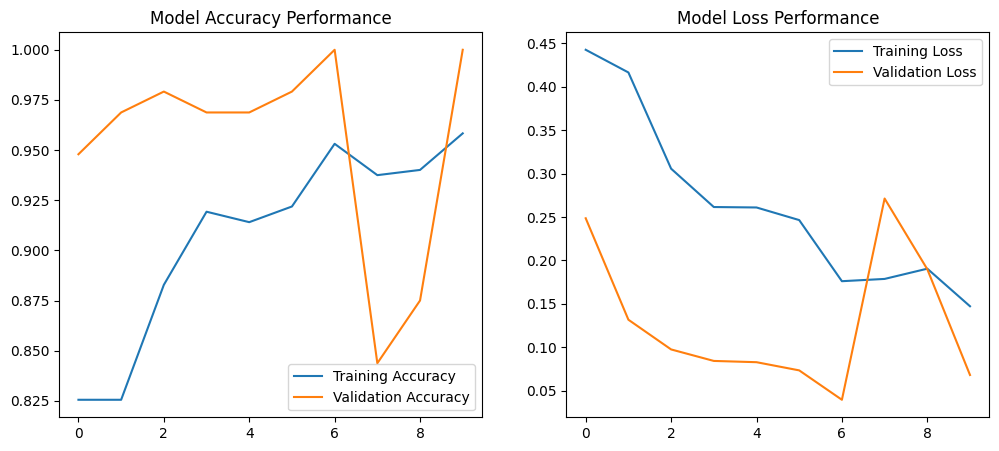


💾 Learning Curves saved to: /content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/results/accuracy_loss_curves.png

[STEP 3] Evaluating Test Data & Generating Confusion Matrix...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 848ms/step


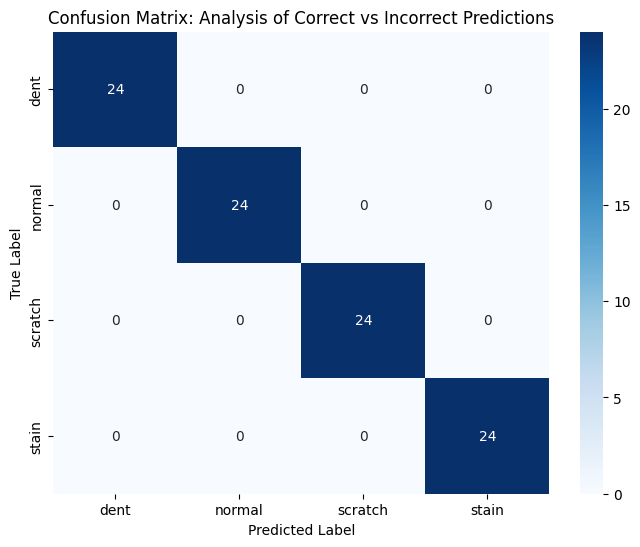


💾 Confusion Matrix saved to: /content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/results/confusion_matrix.png

[STEP 4] Visualizing Sample Predictions on Unseen Data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step


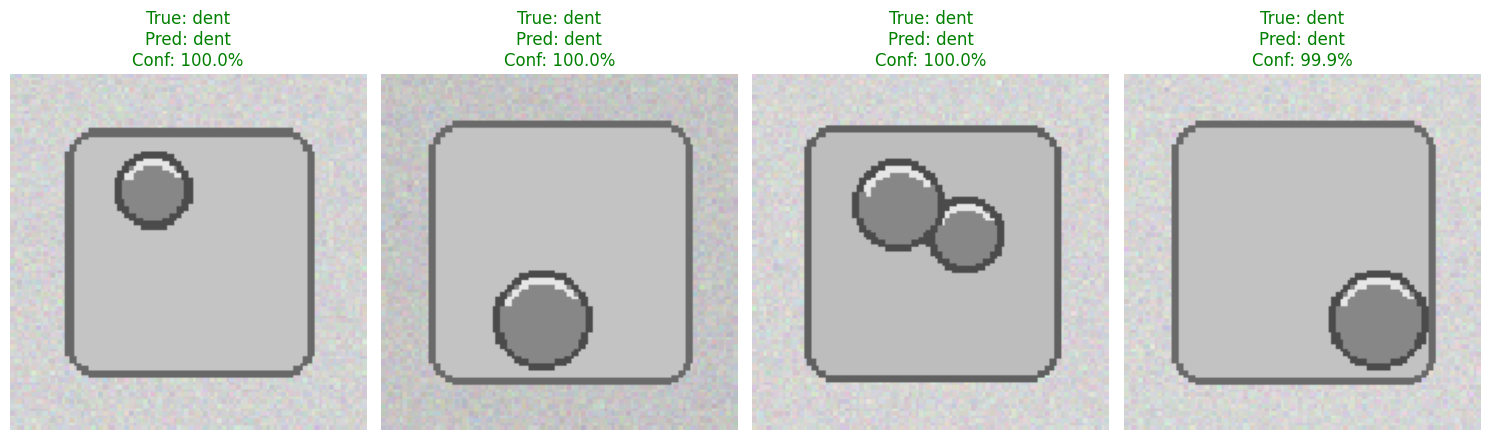


💾 Sample Predictions saved to: /content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/sample_predictions/prediction_outputs.png

--------------------------------------------------------------------------------
🧠 BRIEF EXPLANATION: EVALUATION & PERSISTENCE SUMMARY
--------------------------------------------------------------------------------

1. MODEL TRAINING LOGIC:
   - The model used the 'fit' method to iterate through the training images.
   - In each epoch, the CNN adjusted weights in its Conv2D and Dense layers
     to minimize 'Categorical Crossentropy' (the error rate).

2. PERFORMANCE CURVE ANALYSIS:
   - ACCURACY: We compare Training vs Validation accuracy to detect Overfitting.
   - LOSS: A decreasing loss indicates the model is gaining confidence.

3. CONFUSION MATRIX LOGIC:
   - This matrix reveals specifically where the model fails (e.g., if it
     struggles to tell the difference between a 'Scratch' and a 'Stain').
   - The diagonal values re

In [8]:
# ==============================================================================
# MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
# PART 2: TASK 5 - MODEL TRAINING AND EVALUATION
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n"+ "=" *80)
print("🏋️  TASK 5: MODEL TRAINING AND PERFORMANCE EVALUATION")
print("="*80)

# --- DIRECTORY AND PERSISTENCE SETUP ---
import os
from google.colab import drive

# 1. Mount Google Drive (Standard mount - handles existing mounts gracefully)
drive.mount('/content/drive')

# 2. Define Absolute Paths for the Project
PROJECT_HOME = '/content/drive/My Drive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/'
RESULTS_DIR = os.path.join(PROJECT_HOME, 'results/')
PRED_DIR = os.path.join(PROJECT_HOME, 'sample_predictions/')

# 3. Create Directories (exist_ok=True prevents errors if they already exist)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

print("\n" + "="*80)
print("📂 DIRECTORY AUDIT")
print(f"✅ Results Directory Ready: {RESULTS_DIR}")
print(f"✅ Predictions Directory Ready: {PRED_DIR}")
print("="*80)


# --- STEP 1: MODEL TRAINING ---
print("\n" + "="*80)
print("[STEP 1] Starting Model Training (Epochs: 10)...")
# Training the model using the preprocessed generators.
# We track 'history' to plot the learning curves later.
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    verbose=1
)
print("\n✅ Training Cycle Completed Successfully.")

# --- STEP 2: VISUALIZING ACCURACY AND LOSS ---
print("\n" + "="*80)
print("[STEP 2] Generating Learning Curves (Accuracy & Loss)...")
print("="*80)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy Performance')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss Performance')
plt.legend(loc='upper right')

# --- SAVE THE .PNG ---
save_path_curves = os.path.join(RESULTS_DIR, 'accuracy_loss_curves.png')
plt.savefig(save_path_curves, facecolor='white', transparent=False)
# ----------------------

# Visual Display of Learning Curves
plt.show()
print(f"\n💾 Learning Curves saved to: {save_path_curves}")


# --- STEP 3: CONFUSION MATRIX EVALUATION ---
print("\n" + "="*80)
print("[STEP 3] Evaluating Test Data & Generating Confusion Matrix...")
print("="*80)

# Reset generator and predict
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Plotting Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix: Analysis of Correct vs Incorrect Predictions')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# --- SAVE THE .PNG ---
save_path_cm = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
plt.savefig(save_path_cm, facecolor='white', transparent=False)
# ----------------------

# Visual Display of Confusion Matrix
plt.show()
print(f"\n💾 Confusion Matrix saved to: {save_path_cm}")


# --- STEP 4: SAMPLE PREDICTIONS ON TEST IMAGES ---
print("\n" + "="*80)
print("[STEP 4] Visualizing Sample Predictions on Unseen Data...")
print("="*80)


# Fetch batch of test images
test_images, test_labels = next(test_generator)
sample_preds = model.predict(test_images)

plt.figure(figsize=(15, 8))
for i in range(4): # Show top 4 samples
    plt.subplot(1, 4, i+1)
    plt.imshow(test_images[i])

    actual_idx = np.argmax(test_labels[i])
    pred_idx = np.argmax(sample_preds[i])
    confidence = np.max(sample_preds[i]) * 100

    color = 'green' if actual_idx == pred_idx else 'red'

    plt.title(f"True: {class_labels[actual_idx]}\nPred: {class_labels[pred_idx]}\nConf: {confidence:.1f}%", color=color)
    plt.axis('off')

plt.tight_layout()

# --- SAVE THE .PNG ---
save_path_preds = os.path.join(PRED_DIR, 'prediction_outputs.png')
plt.savefig(save_path_preds, facecolor='white', transparent=False)
# ----------------------

# Visual Display of Prediction Outputs
plt.tight_layout() # Keep your existing tight_layout()
plt.show()
print(f"\n💾 Sample Predictions saved to: {save_path_preds}")



# --- STEP 5: LOGIC EXPLANATION PRINT STATEMENTS ---
print("\n" + "-"*80)
print("🧠 BRIEF EXPLANATION: EVALUATION & PERSISTENCE SUMMARY")
print("-"*80)

print("\n1. MODEL TRAINING LOGIC:")
print("   - The model used the 'fit' method to iterate through the training images.")
print("   - In each epoch, the CNN adjusted weights in its Conv2D and Dense layers")
print("     to minimize 'Categorical Crossentropy' (the error rate).")

print("\n2. PERFORMANCE CURVE ANALYSIS:")
print("   - ACCURACY: We compare Training vs Validation accuracy to detect Overfitting.")
print("   - LOSS: A decreasing loss indicates the model is gaining confidence.")

print("\n3. CONFUSION MATRIX LOGIC:")
print("   - This matrix reveals specifically where the model fails (e.g., if it")
print("     struggles to tell the difference between a 'Scratch' and a 'Stain').")
print("   - The diagonal values represent correct classifications.")

print("\n4. FINAL PREDICTION LOGIC:")
print("   - The 'Softmax' layer provides a probability score for each class.")
print("   - We take the 'Argmax' (highest score) to decide the final defect label.")
print("   - High confidence (>90%) suggests the model has learned robust features.")

print("\n5. DIRECTORY & PERSISTENCE LOGIC:")
print("   - AUTOMATED SETUP: Used 'os.makedirs' with 'exist_ok=True' to ensure ")
print("     folders exist without triggering errors on repeat executions.")
print("   - DRIVE SYNC: Standardized mounting ensures the environment links")
print("     directly to Google Drive for permanent storage of results.")

print("\n6. EXPORT & VISUALIZATION LOGIC:")
print("   - SAVE-THEN-SHOW: Captured plots to PNG files before clearing the")
print("     Matplotlib buffer to prevent blank image exports.")
print("   - TIGHT LAYOUT: Optimized subplot spacing to ensure titles and labels")
print("     do not overlap in the final saved 'prediction_outputs.png'.")

print("\n" + "="*80)
print("✅ TASK 5 COMPLETE: PROTOTYPE TRAINING, EVALUATION, AND EXPORT FINISHED")
print("="*80)


In [1]:
# ==============================================================================
# MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
# PART 2: TASK 6 - CNN CONCEPTUAL EXPLANATION
# ==============================================================================

print("="*80)
print("🧠 TASK 6: CONVOLUTIONAL NEURAL NETWORK (CNN) CONCEPTS")
print("="*80)

# The core explanation for these technical concepts is maintained in the documentation
print("\n📝 The detailed answer to this task is in the README.md file.")

print("\n" + "="*80)


🧠 TASK 6: CONVOLUTIONAL NEURAL NETWORK (CNN) CONCEPTS

📝 The detailed answer to this task is in the README.md file.



In [2]:
# ==============================================================================
# MODULE 5: APPLIED NEURAL NETWORKS & COMPUTER VISION
# PART 2: TASK 7 - BUSINESS USE CASE MAPPING
# ==============================================================================

print("="*80)
print("💼 TASK 7: BUSINESS USE CASE MAPPING - COMPUTER VISION IN FINANCE")
print("="*80)


# --- STEP 1: EXPLAINING THE DOMAIN TRANSFORMATION ---
print("\n[DOMAIN][My Favourite]: Stock Market Investment & Trading")
print("Covered various Retail and Business aspects where Computer Vision can be applied")
print("-" * 80)

print("\n📌 CORE CONCEPT: 'CHART PATTERN RECOGNITION'")
print("   - Just as our CNN identified 'Scratches' or 'Dents' in surface images,")
print("     it can be trained to identify 'Visual Patterns' in financial charts.")
print("   - By converting time-series price data into 2D images (Candlestick charts),")
print("     a CNN can 'see' market sentiment.")

# --- STEP 2: REAL-WORLD APPLICATIONS ---
print("\n🚀 KEY BUSINESS APPLICATIONS:")

print("\n🔹 Automated Technical Analysis")
print("   * CNNs can scan thousands of stocks per second to find specific shapes:")
print("     - Head and Shoulders (Reversal signals)")
print("     - Double Bottoms (Support levels)")
print("     - Cup and Handle (Breakout patterns)")
print("   * Benefit: Eliminates human bias and fatigue in chart analysis.")

print("\n🔹 Algorithmic Trading Triggers")
print("   * The model acts as a 'Visual Sensor' for high-frequency trading bots.")
print("   * When the CNN detects a high-probability bullish pattern, it can")
print("     automatically trigger a 'Buy' order in milliseconds.")

print("\n🔹 Sentiment Analysis via Heatmaps")
print("   * Traders use 'Market Heatmaps' to see which sectors are gaining heat.")
print("   * A CNN can analyze the density and color distribution of these maps")
print("     to predict sector rotation and capital flow.")

# ==============================================================================
# ADDITIONAL BUSINESS USE CASES (FINANCE)
# ==============================================================================

print("\n🚀 ADVANCED BUSINESS APPLICATIONS:")

print("\n🔹 Alternative Data: Satellite Imagery Analysis")
print("   * Large investment firms use CNNs to analyze satellite photos of:")
print("     - Retailer Parking Lots: High car counts predict strong quarterly sales.")
print("     - Oil Tankers: Monitoring shadows on floating lids to estimate global oil supply.")
print("   * Benefit: Provides 'Alpha' (market edge) before official reports are released.")

print("\n🔹 Real-Time Document & News Digitization")
print("   * CNNs are used in OCR (Optical Character Recognition) to scan:")
print("     - Handwritten financial ledgers and physical bank statements.")
print("     - Tables in thousands of PDF earning reports.")
print("   * Benefit: Converts unstructured physical data into tradeable digital signals.")

print("\n🔹 Trading Floor Surveillance & Risk Management")
print("   * In high-stakes trading floors, Computer Vision monitors 'Human Risk':")
print("     - Facial Expression Analysis: Detecting extreme stress or panic in traders.")
print("     - Unusual Activity: Flagging unauthorized access to secure trading terminals.")
print("   * Benefit: Protects the firm from 'Fat Finger' errors or rogue trading behavior.")

print("\n🔹 Fraud Detection in Digital Transactions")
print("   * Using CNNs to detect 'Visual Anomalies' in:")
print("     - Digital check signatures (finding subtle forgery).")
print("     - Counterfeit identity documents during digital KYC (Know Your Customer) onboarding.")
print("   * Benefit: Dramatically reduces financial loss from identity theft.")


print("\n" + "="*80)
print("✅ TASK 7 COMPLETE: Business mapping for Finance is finalized.")
print("="*80)

💼 TASK 7: BUSINESS USE CASE MAPPING - COMPUTER VISION IN FINANCE

[DOMAIN][My Favourite]: Stock Market Investment & Trading
Covered various Retail and Business aspects where Computer Vision can be applied
--------------------------------------------------------------------------------

📌 CORE CONCEPT: 'CHART PATTERN RECOGNITION'
   - Just as our CNN identified 'Scratches' or 'Dents' in surface images,
     it can be trained to identify 'Visual Patterns' in financial charts.
   - By converting time-series price data into 2D images (Candlestick charts),
     a CNN can 'see' market sentiment.

🚀 KEY BUSINESS APPLICATIONS:

🔹 Automated Technical Analysis
   * CNNs can scan thousands of stocks per second to find specific shapes:
     - Head and Shoulders (Reversal signals)
     - Double Bottoms (Support levels)
     - Cup and Handle (Breakout patterns)
   * Benefit: Eliminates human bias and fatigue in chart analysis.

🔹 Algorithmic Trading Triggers
   * The model acts as a 'Visual Sensor' 